# 3. Compare baseline alternatives
Goal: explore various interpolations on discrete cases (images), and compare their performance

In [1]:
#============= Globals ==========

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from src.general_utils import prepare_environment, SCV_FILES, BRAIN_PLANES
from src.data_utils import load_metadata, load_volume, csv_path_to_local_path, min_max_normalize
from src.k_space_utils import image_to_kspace, kspace_to_image, zero_k_space_rows_normal_random_dist
from src.reconstruction import interpolation_reconstruction
from src.metrices import calculate_image_quality_metrics
HPC = False

#============= Experiment Parameters  ==========

RANDOM_SEED = 1948
IMAGES_PER_PLANE = 10
RANGE_IN_PLANE_PERCENTAGE_TO_SELECT = 50
DROPPED_LINES = 70
SHOW_IMAGES = False
INTERPOLATION_TOLERANCE = 1e-3

METHODS = {
    'Zero Filling': 'zero_filling',
    'Nearest Row':  'nearest_row',
    'Linear 1D':    'linear_1d',
    'Bilinear':     'bilinear',
    'Bicubic':      'bicubic',
}
METRIC_KEYS    = ['psnr', 'ssim', 'nrmse', 'mae', 'hfen']
METRIC_DISPLAY = ['PSNR', 'SSIM', 'NRMSE', 'MAE', 'HFEN']

#============= main ==========
prepare_environment(hpc=HPC)
np.random.seed(RANDOM_SEED)

Data path: C:\mri_dataset\brain_age


## Compare the methods on a small baseline of images
Use parameters to control the experiment: number of images, range in plane percentage, dropped lines, and whether to show images.


In [2]:
#=============functions ==========

def pick_random_slice(volume, axis, range_pct, rng_instance):
    """Return (slice_index, 2-D slice) drawn from the central range_pct % of the axis."""
    n = volume.shape[axis]
    margin = int(n * (1.0 - range_pct / 100.0) / 2)
    lo = max(0, margin)
    hi = min(n - 1, n - margin - 1)
    if lo >= hi:
        lo, hi = 0, n - 1
    idx = int(rng_instance.integers(lo, hi + 1))
    sel = [slice(None), slice(None), slice(None)]
    sel[axis] = idx
    return idx, volume[tuple(sel)]

def safe_metrics(reference, reconstructed):
    try:
        return calculate_image_quality_metrics(reference, reconstructed)
    except Exception:
        return {k: float('nan') for k in METRIC_KEYS}

#============= main ==========

train_df = load_metadata(SCV_FILES['train'])
print(f'Train rows: {len(train_df)}')

rng = np.random.default_rng(RANDOM_SEED)
max_trials = min(len(train_df), max(200, 20 * IMAGES_PER_PLANE))
candidate_indices = rng.permutation(len(train_df))[:max_trials]

volumes = []
for idx in candidate_indices:
    row   = train_df.iloc[idx]
    local = Path(csv_path_to_local_path(row['filePath']))
    vol   = load_volume(local)
    if vol is not None:
        volumes.append(vol)
    if len(volumes) >= IMAGES_PER_PLANE * len(BRAIN_PLANES):
        break

print(f'Loaded {len(volumes)} usable volumes')

for plane_name, axis in BRAIN_PLANES.items():

    # accumulate per-method lists of metric dicts
    plane_metrics = {label: [] for label in METHODS}

    plane_rng  = np.random.default_rng(RANDOM_SEED + axis * 7919)
    n_cases    = min(IMAGES_PER_PLANE, len(volumes))
    vol_picks  = plane_rng.choice(len(volumes), size=n_cases, replace=False)

    for case_num, vol_idx in enumerate(vol_picks, start=1):
        volume = volumes[vol_idx]

        slice_idx, raw_slice = pick_random_slice(
            volume, axis, RANGE_IN_PLANE_PERCENTAGE_TO_SELECT, plane_rng
        )
        normalized    = min_max_normalize(raw_slice)
        k_space       = image_to_kspace(normalized)
        harmed_k_space, zero_lines_indices = zero_k_space_rows_normal_random_dist(
            k_space, n=DROPPED_LINES,
            seed=int(plane_rng.integers(0, 2**31)),
            sigma_fraction=1/6,
        )
        damaged_image = kspace_to_image(harmed_k_space)

        if SHOW_IMAGES:
            n_cols = 2 + len(METHODS)
            fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
            axes[0].imshow(normalized,    cmap='gray'); axes[0].set_title('Normalized')
            axes[1].imshow(damaged_image, cmap='gray'); axes[1].set_title(f'Damaged ({DROPPED_LINES} lines)')

        for m_idx, (method_label, method_key) in enumerate(METHODS.items()):
            recon, _ = interpolation_reconstruction(
                harmed_k_space,
                zero_lines_indices=zero_lines_indices,
                method=method_key,
            )
            plane_metrics[method_label].append(safe_metrics(normalized, recon))

            if SHOW_IMAGES:
                axes[2 + m_idx].imshow(recon, cmap='gray')
                axes[2 + m_idx].set_title(method_label)

        if SHOW_IMAGES:
            for ax in axes: ax.axis('off')
            fig.suptitle(
                f'{plane_name} | case {case_num}/{n_cases} | slice {slice_idx}',
                fontsize=12
            )
            plt.tight_layout(); plt.show()

    # ── summary table ────────────────────────────────────────────────────
    rows = {}
    for method_label, metrics_list in plane_metrics.items():
        row = {}
        for mk, md in zip(METRIC_KEYS, METRIC_DISPLAY):
            vals = np.array([m[mk] for m in metrics_list])
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                row[md] = 'N/A'
            else:
                mean = vals.mean()
                std  = vals.std(ddof=0)
                row[md] = f'{mean:.1f}±{std:.1f}'
        rows[method_label] = row

    summary_df = pd.DataFrame(rows).T[METRIC_DISPLAY]
    print(f'\n=== {plane_name} plane  |  {n_cases} images  |  {DROPPED_LINES} dropped lines ===')
    display(summary_df)


Train rows: 4233
Loaded 30 usable volumes

=== sagittal plane  |  10 images  |  70 dropped lines ===


,PSNR,SSIM,NRMSE,MAE,HFEN
Zero Filling,25.6±1.8,0.7±0.0,0.2±0.0,0.0±0.0,0.4±0.0
Nearest Row,24.0±1.7,0.6±0.0,0.3±0.0,0.0±0.0,0.5±0.1
Linear 1D,24.9±1.7,0.6±0.0,0.2±0.0,0.0±0.0,0.4±0.1
Bilinear,24.9±1.7,0.6±0.0,0.2±0.0,0.0±0.0,0.4±0.1
Bicubic,24.1±1.8,0.6±0.0,0.4±0.1,0.1±0.0,0.5±0.1



=== coronal plane  |  10 images  |  70 dropped lines ===


,PSNR,SSIM,NRMSE,MAE,HFEN
Zero Filling,20.7±0.7,0.7±0.0,0.2±0.0,0.0±0.0,0.6±0.1
Nearest Row,18.0±2.8,0.6±0.1,0.5±0.2,0.1±0.0,0.8±0.1
Linear 1D,19.2±1.6,0.6±0.0,0.4±0.1,0.1±0.0,0.8±0.1
Bilinear,19.2±1.6,0.6±0.0,0.4±0.1,0.1±0.0,0.8±0.1
Bicubic,17.2±2.9,0.5±0.1,0.6±0.2,0.1±0.0,1.0±0.4



=== axial plane  |  10 images  |  70 dropped lines ===


,PSNR,SSIM,NRMSE,MAE,HFEN
Zero Filling,21.1±1.7,0.7±0.0,0.3±0.1,0.1±0.0,0.6±0.0
Nearest Row,19.5±2.2,0.6±0.0,0.4±0.1,0.1±0.0,0.8±0.1
Linear 1D,20.3±2.0,0.6±0.0,0.4±0.1,0.1±0.0,0.7±0.1
Bilinear,20.3±2.0,0.6±0.0,0.4±0.1,0.1±0.0,0.7±0.1
Bicubic,19.2±2.5,0.5±0.1,0.5±0.2,0.1±0.1,1.0±0.5


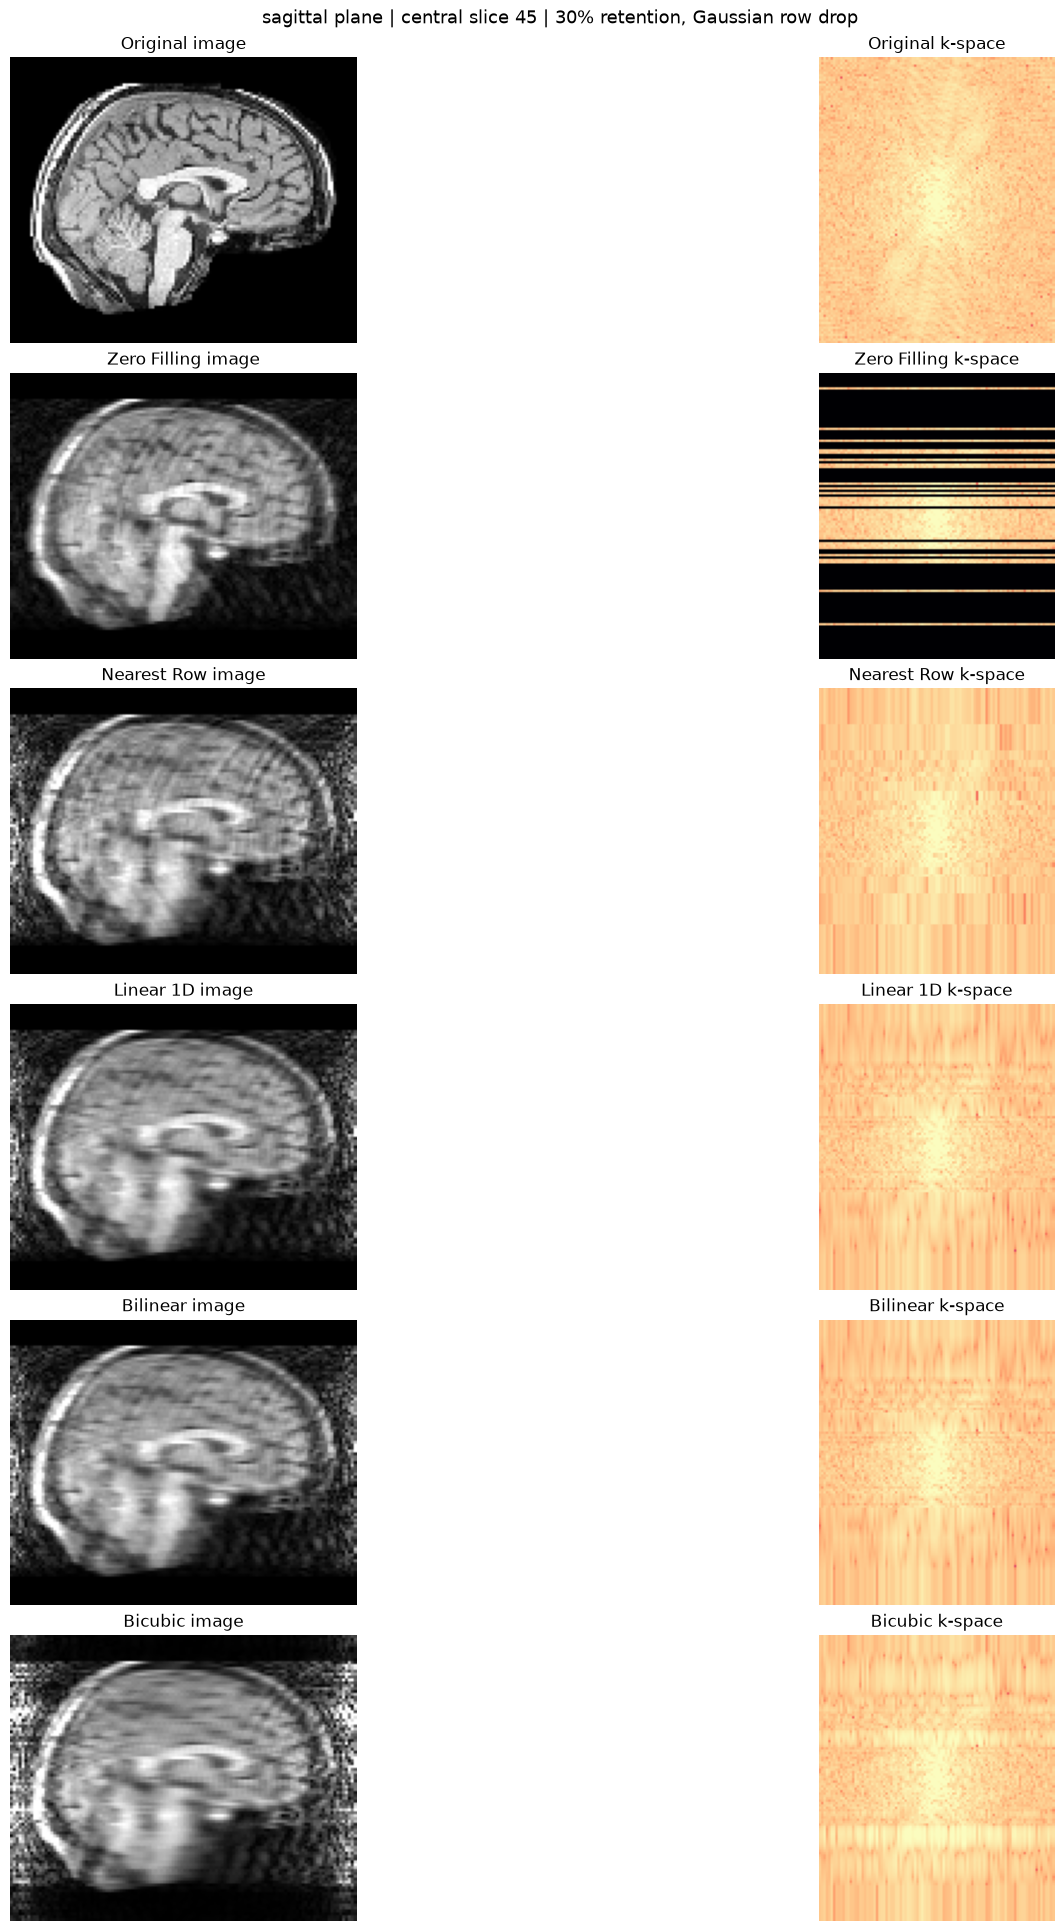

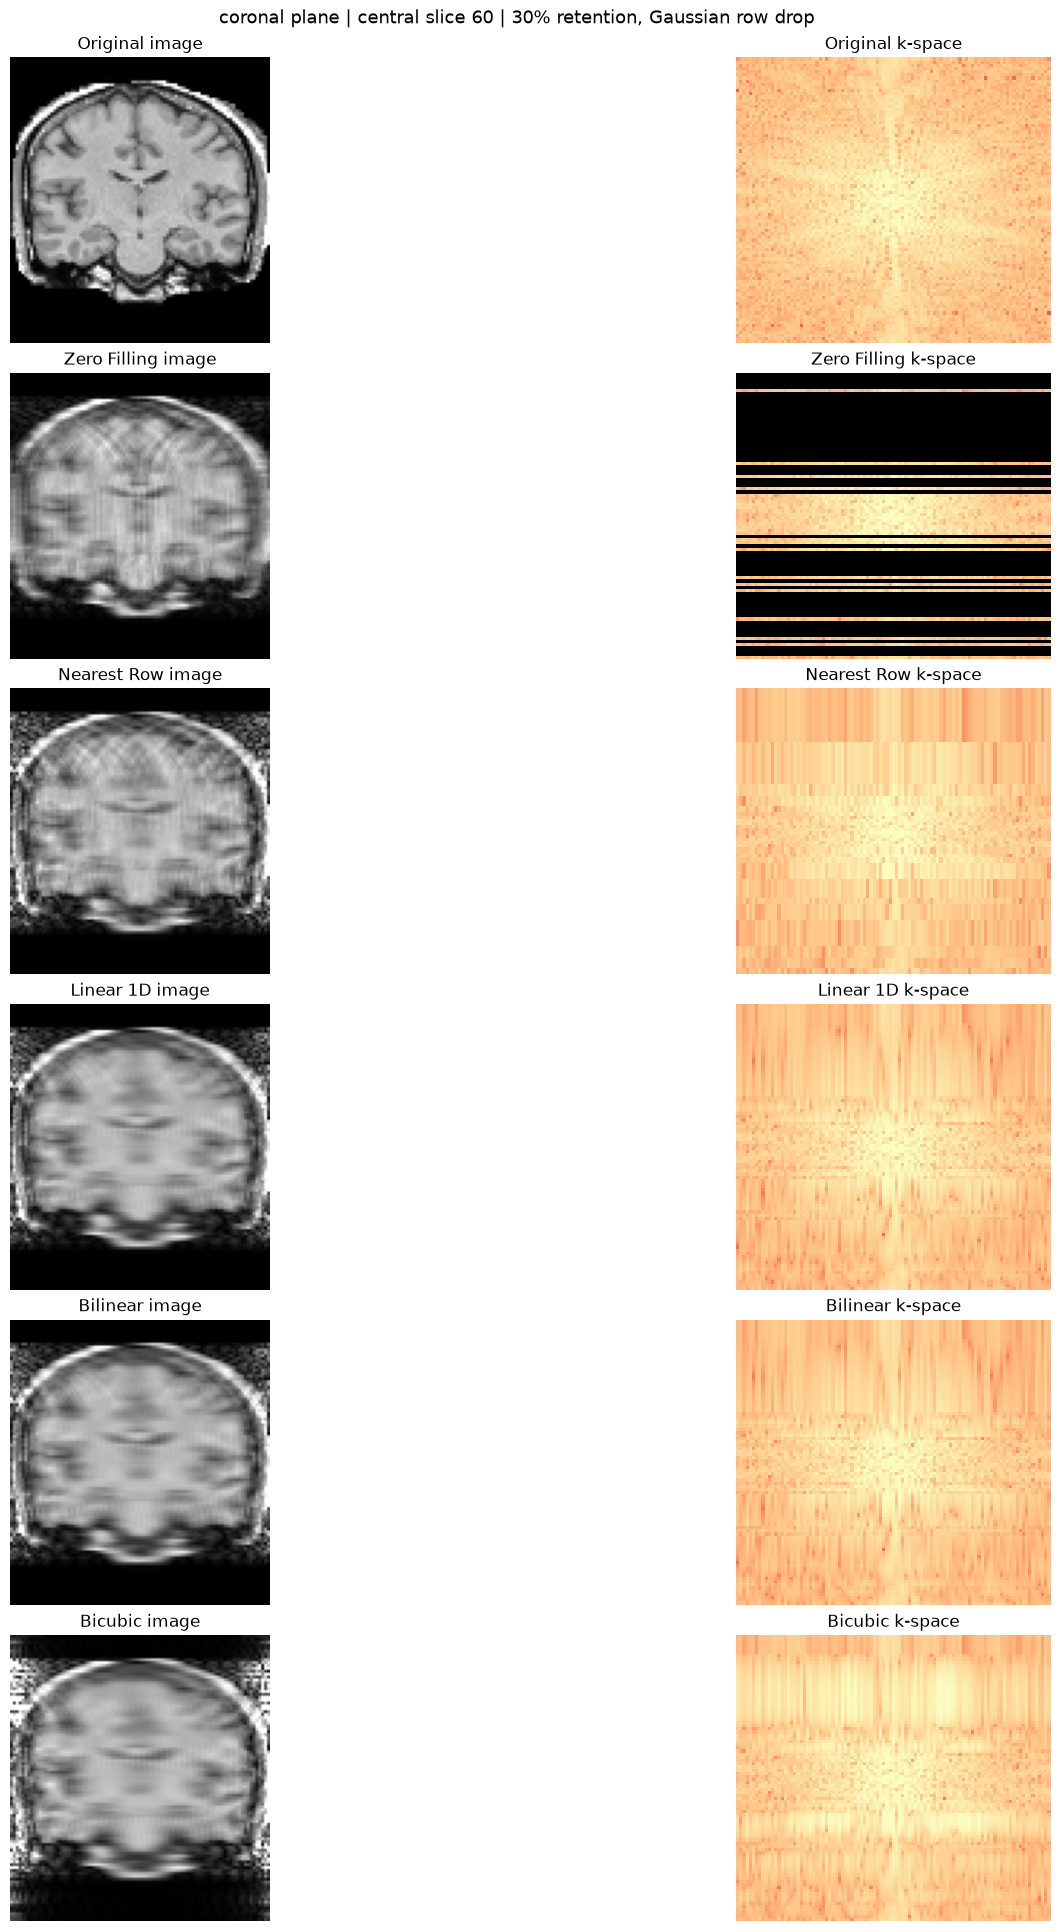

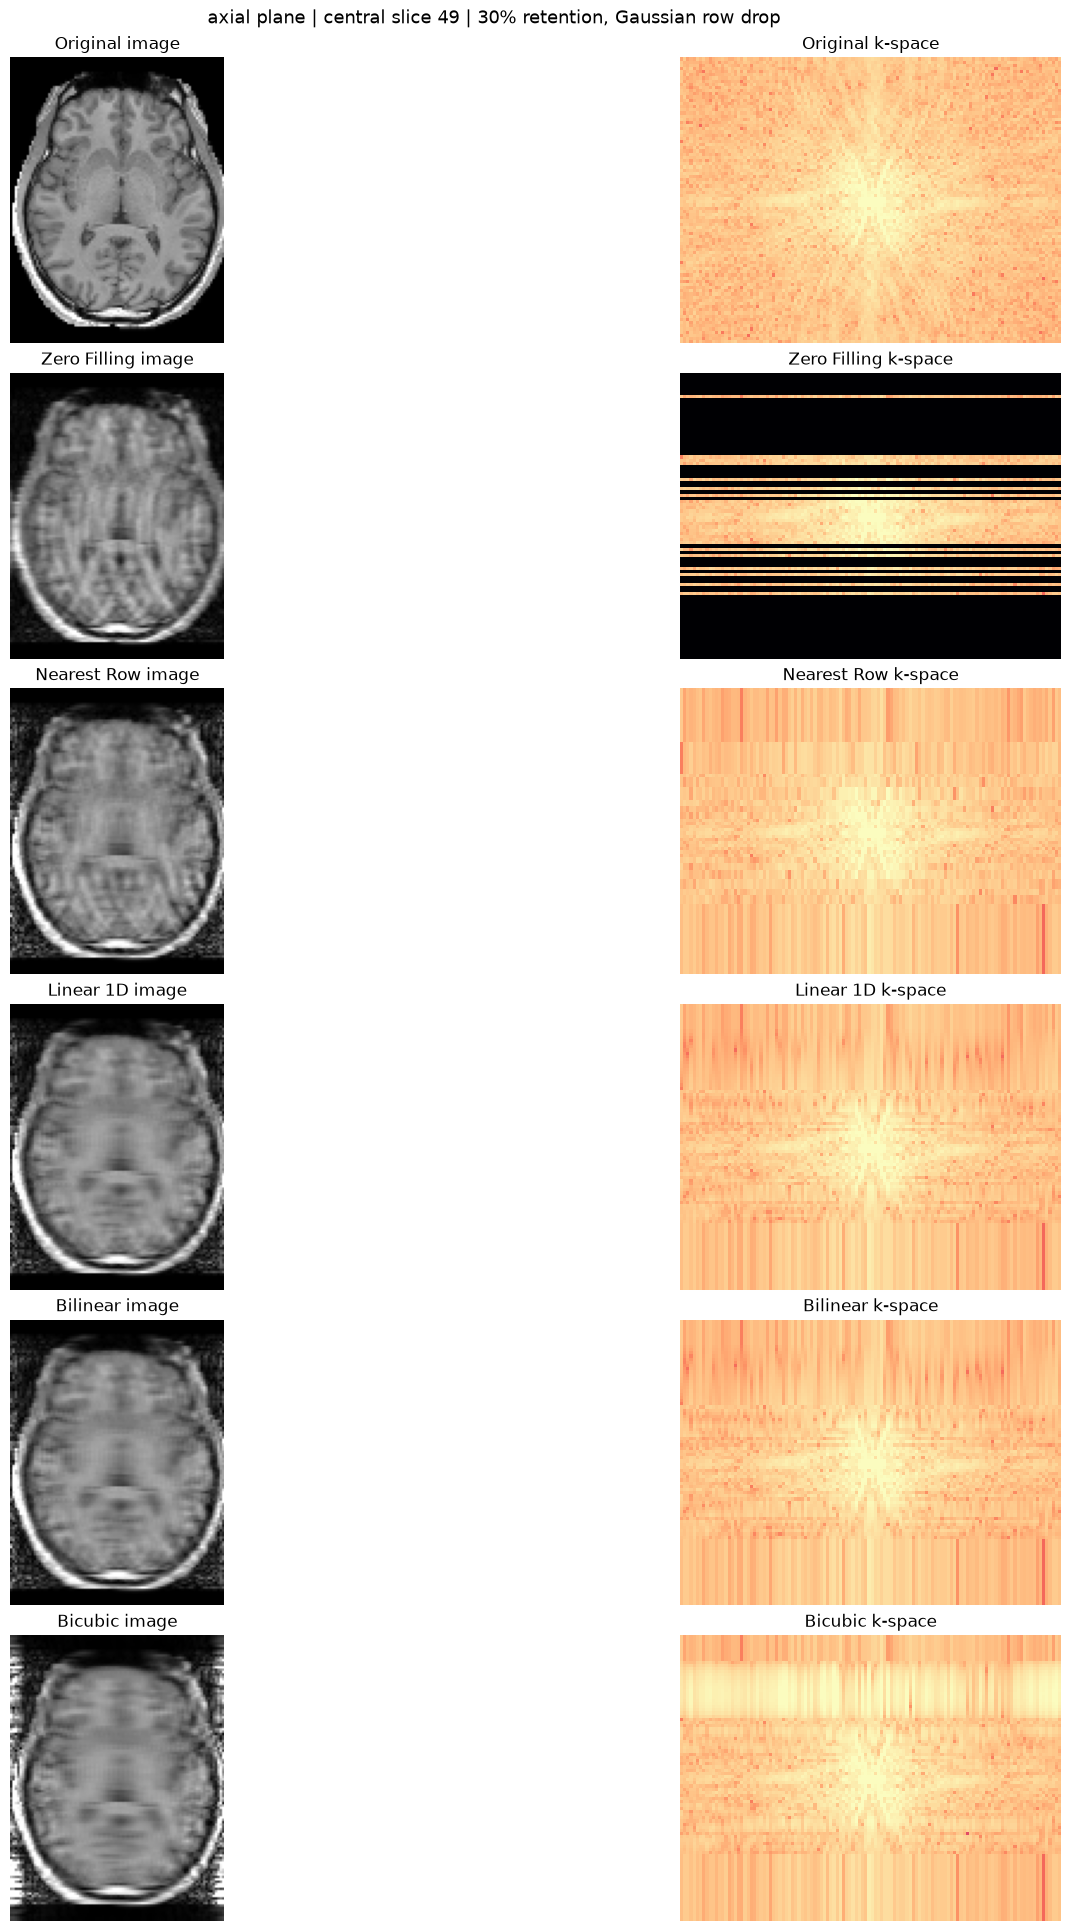

In [3]:
from src.k_space_utils import kspace_log_magnitude
VIS_METHODS = list(METHODS.items())
VIS_RETAIN_RATIO = 0.30
VIS_ZERO_FRACTION = 1.0 - VIS_RETAIN_RATIO
VIS_SIGMA_FRACTION = 1 / 6
def central_plane_slice(volume, axis):
    slice_idx = volume.shape[axis] // 2
    selectors = [slice(None)] * volume.ndim
    selectors[axis] = slice_idx
    return slice_idx, volume[tuple(selectors)]
if len(volumes) < len(BRAIN_PLANES):
    raise ValueError(
        f'Need at least {len(BRAIN_PLANES)} volumes to build one comparison per plane; '
        f'found {len(volumes)}.'
    )
comparison_rng = np.random.default_rng(RANDOM_SEED + 2026)
selected_volume_indices = comparison_rng.choice(
    len(volumes),
    size=len(BRAIN_PLANES),
    replace=False,
)
for (plane_name, axis), volume_idx in zip(BRAIN_PLANES.items(), selected_volume_indices):
    volume = volumes[int(volume_idx)]
    slice_idx, raw_slice = central_plane_slice(volume, axis)
    normalized = min_max_normalize(raw_slice)
    original_k_space = image_to_kspace(normalized)
    rows_to_zero = int(round(VIS_ZERO_FRACTION * original_k_space.shape[0]))
    harmed_k_space, zero_lines_indices = zero_k_space_rows_normal_random_dist(
        original_k_space,
        n=rows_to_zero,
        seed=int(comparison_rng.integers(0, 2**31 - 1)),
        sigma_fraction=VIS_SIGMA_FRACTION,
    )
    panel_titles = [('Original', normalized, original_k_space)]
    for method_label, method_key in VIS_METHODS:
        reconstructed, corrected_k_space = interpolation_reconstruction(
            harmed_k_space,
            zero_lines_indices=zero_lines_indices,
            method=method_key,
        )
        panel_titles.append((method_label, reconstructed, corrected_k_space))
    image_stack = np.stack([panel[1] for panel in panel_titles], axis=0)
    kspace_stack = np.stack([kspace_log_magnitude(panel[2]) for panel in panel_titles], axis=0)
    image_vmin = float(np.percentile(image_stack, 1))
    image_vmax = float(np.percentile(image_stack, 99))
    kspace_vmin = float(np.percentile(kspace_stack, 1))
    kspace_vmax = float(np.percentile(kspace_stack, 99))
    fig, axes = plt.subplots(
        nrows=len(panel_titles),
        ncols=2,
        figsize=(15, 3.2 * len(panel_titles)),
        constrained_layout=True,
    )
    if len(panel_titles) == 1:
        axes = np.array([axes])
    for row_idx, (row_title, image_panel, kspace_panel) in enumerate(panel_titles):
        ax_img, ax_ksp = axes[row_idx]
        ax_img.imshow(np.rot90(image_panel), cmap='gray', vmin=image_vmin, vmax=image_vmax)
        ax_img.set_title(f'{row_title} image')
        ax_img.axis('off')
        ax_ksp.imshow(
            kspace_log_magnitude(kspace_panel),
            cmap='magma',
            vmin=kspace_vmin,
            vmax=kspace_vmax,
        )
        if row_idx == 0:
            ax_ksp.set_title('Original k-space')
        else:
            ax_ksp.set_title(f'{row_title} k-space')
        ax_ksp.axis('off')
    fig.suptitle(
        f'{plane_name} plane | central slice {slice_idx} | 30% retention, Gaussian row drop',
        fontsize=13,
    )
    plt.show()


## Intermediate observations:
The base-alternative evaluation shows that zero filling consistently outperformed all interpolation-based reconstruction methods across the sagittal, coronal, and axial planes.
It achieved the highest PSNR and SSIM values and the lowest NRMSE and HFEN in every orientation, indicating better overall intensity fidelity, structural preservation, and edge consistency.

When inspecting the interpolation methods, linear 1D and bilinear interpolation produced nearly identical results and were generally the strongest alternatives, but neither improved upon zero filling.

Nearest-row interpolation performed worse, while bicubic interpolation was consistently the weakest method, particularly in the coronal and axial planes, where it produced the lowest SSIM and highest NRMSE and HFEN values.

The intermediate results imply that estimating missing k-space rows using simple image-independent interpolation introduces additional errors and artificial frequency content rather than recovering the true missing information.
The differences between planes also indicate that reconstruction difficulty depends on anatomical orientation, with sagittal slices producing substantially higher PSNR than coronal and axial slices.
Overall, zero filling should therefore be retained as the baseline method, while more advanced data-driven or model-based reconstruction is required to achieve meaningful improvement beyond it.
